In [38]:
%matplotlib inline
## Load full-library modisco (per ct), annotate via cached TOMTOM (JASPAR2026),
## partition full-lib finemo hits by quadrant, run motif-level enrichment (Fisher's exact).
import os, sys, json, h5py, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import fisher_exact

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
from eigen_steering import EigenMap
import eigen_steering as es
es._load_heavy_deps()
fast_logo = es.fast_logo

CT  = {'K562': 'K562_twostep_v6_do075', 'HepG2': 'HepG2_twostep_v6_do03'}
CTS = ['HepG2', 'K562']
QUADS = [1, 2, 3, 4]
MODISCO_DIR = os.path.join(REPO, 'genomic_targets/data/modisco')
FULL_H5     = lambda ct: os.path.join(MODISCO_DIR, f'{ct}_full56k_enh230_default.h5')
HITS_TSV    = lambda ct: os.path.join(REPO, 'genomic_targets/data/motif', ct, 'hits.tsv')
FULL_TOMTOM = os.path.join(MODISCO_DIR, 'tomtom_jaspar2026_full56k_enh230_default.json')
full_ann    = json.load(open(FULL_TOMTOM)) if os.path.exists(FULL_TOMTOM) else {}

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{c}_log2FC' for c in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device='cpu')
em.load_from_dataframe(df, seq_col='sequence')

raw = np.load(os.path.join(REPO, 'genomic_targets/data/deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n_full = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{c}_log2FC' for c in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for c in CT:
    hyp = raw[f'attr_{c}'][:n_full][keep]
    em.attr_hyp[c]   = hyp
    em.attr[c]       = hyp * ohe
    em.importance[c] = em.attr[c].sum(axis=1)

cossim = em.cosine_similarity(mode='importance', zscore=True)
lfc    = df['HepG2_log2FC'].values - df['K562_log2FC'].values
fin    = np.isfinite(cossim) & np.isfinite(lfc)

def quad_mask(q):
    if q == 1: return fin & (cossim >= 0) & (lfc >= 0)
    if q == 2: return fin & (cossim >= 0) & (lfc <  0)
    if q == 3: return fin & (cossim <  0) & (lfc <  0)
    return       fin & (cossim <  0) & (lfc >= 0)

quad_indices = {q: np.where(quad_mask(q))[0] for q in QUADS}
quad_n       = {q: len(quad_indices[q]) for q in QUADS}
n_seqs       = len(df)
quad_of      = np.zeros(n_seqs, dtype=int)
for q in QUADS: quad_of[quad_indices[q]] = q

# motif catalogue from full-lib modisco h5 (per ct)
motifs = {}
for ct in CTS:
    lst = []
    with h5py.File(FULL_H5(ct)) as f:
        for grp in ('pos_patterns', 'neg_patterns'):
            if grp not in f: continue
            for pname in f[grp]:
                key = f'{grp}.{pname}'
                lst.append({'motif': key, 'sign': 'pos' if grp.startswith('pos') else 'neg',
                            'tf': full_ann.get(f'{ct}/{key}', '')})
    motifs[ct] = pd.DataFrame(lst)

# full-lib finemo hits, partitioned by quadrant
hits = {}
for ct in CTS:
    h = pd.read_csv(HITS_TSV(ct), sep='\t',
                    usecols=['peak_id', 'motif_name', 'hit_importance'])
    h['peak_id'] = h['peak_id'].astype(int)
    h = h[h['peak_id'] < n_seqs]
    h['q'] = quad_of[h['peak_id'].values]
    h = h[h['q'] != 0]
    hits[ct] = h

# motif-level enrichment: per (ct, motif, q), Fisher's exact one-sided
# 2x2: [hits-of-motif in q, hits-other-motifs in q] vs [hits-of-motif elsewhere, hits-other-motifs elsewhere]
enrich_rows = []
for ct in CTS:
    h = hits[ct]
    N = len(h)
    by_mq = (h.groupby(['motif_name', 'q']).size()
              .unstack('q', fill_value=0).reindex(columns=QUADS, fill_value=0))
    n_per_q = h.groupby('q').size().reindex(QUADS, fill_value=0)
    for motif, row in by_mq.iterrows():
        K = int(row.sum())
        for q in QUADS:
            k = int(row[q]); n_q = int(n_per_q[q])
            if k == 0: continue
            table = [[k, n_q - k], [K - k, (N - n_q) - (K - k)]]
            odds, p = fisher_exact(table, alternative='greater')
            enrich_rows.append({'ct': ct, 'q': q, 'motif': motif,
                                'tf': full_ann.get(f'{ct}/{motif}', ''),
                                'k_in_q': k, 'K_total': K, 'q_total_hits': n_q,
                                'odds_ratio': odds, 'p': p})
enrich = pd.DataFrame(enrich_rows).sort_values(['ct', 'q', 'p']).reset_index(drop=True)

print(f'quad sizes (seqs)  Q1={quad_n[1]}  Q2={quad_n[2]}  Q3={quad_n[3]}  Q4={quad_n[4]}')
print('\nfull-lib patterns / ct:', {ct: len(motifs[ct]) for ct in CTS})
print('full-lib finemo hits / ct (q>0):',
      {ct: f'{len(hits[ct])} ({dict(hits[ct].groupby("q").size())})' for ct in CTS})
for ct in CTS:
    print(f'\n=== {ct} top-enriched motifs per quadrant (Fisher one-sided, full-lib hits) ===')
    sub = enrich[enrich['ct'] == ct]
    top = sub.sort_values(['q', 'p']).groupby('q', as_index=False).head(8)
    print(top[['q', 'motif', 'tf', 'k_in_q', 'K_total', 'q_total_hits', 'odds_ratio', 'p']].to_string(index=False))

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_twostep_v6_do075', 'HepG2': 'HepG2_twostep_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
quad sizes (seqs)  Q1=23337  Q2=30663  Q3=492  Q4=2483

full-lib patterns / ct: {'HepG2': 35, 'K562': 40}
full-lib finemo hits / ct (q>0): {'HepG2': '151632 ({1: np.int64(68841), 2: np.int64(72634), 3: np.int64(1053), 4: np.int64(9104)})', 'K562': '143475 ({1: np.int64(55233), 2: np.int64(82488), 3: np.int64(1091), 4: np.int64(4663)})'}

=== HepG2 top-enriched motifs per quadrant (Fisher one-sided, full-lib hits) ===
 q                   motif                 tf  k_in_q  K_total  q_total_hits  odds_ratio             p
 1  pos_patterns.pattern_2 MA1141.2 FOS::JUND    7508    12590         68841    1.871831 2.247336e-245
 1  pos_patterns.pattern_1     MA0484.3 HNF4G    4632     7892         68841    1.759914 1.062237e-130
 1 pos_patterns.pattern_13     MA0846.2 FOXC2    3955     6593         68841    1.851998 2.017713e-130
 1

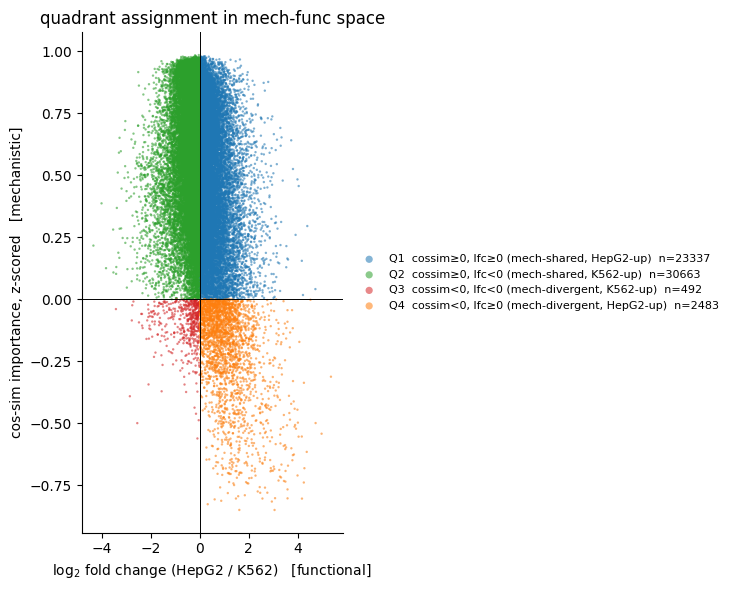

In [39]:
## show on (lfc, cossim) mech-func space where each quadrant's source seqs map
QUAD_COLOR = {1: '#1f77b4', 2: '#2ca02c', 3: '#d62728', 4: '#ff7f0e'}
QUAD_LABEL = {1: 'Q1  cossim≥0, lfc≥0 (mech-shared, HepG2-up)',
              2: 'Q2  cossim≥0, lfc<0 (mech-shared, K562-up)',
              3: 'Q3  cossim<0, lfc<0 (mech-divergent, K562-up)',
              4: 'Q4  cossim<0, lfc≥0 (mech-divergent, HepG2-up)'}

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(lfc[fin], cossim[fin], s=1, c='lightgrey', alpha=0.3,
           edgecolors='none', rasterized=True)
for q in QUADS:
    idx = quad_indices[q]
    ax.scatter(lfc[idx], cossim[idx], s=3, color=QUAD_COLOR[q], alpha=0.55,
               edgecolors='none', rasterized=True,
               label=f'{QUAD_LABEL[q]}  n={quad_n[q]}')
ax.axhline(0, color='k', lw=0.7); ax.axvline(0, color='k', lw=0.7)
ax.set_xlabel('log$_2$ fold change (HepG2 / K562)   [functional]')
ax.set_ylabel('cos-sim importance, z-scored   [mechanistic]')
ax.set_title('quadrant assignment in mech-func space')
ax.legend(frameon=False, fontsize=8, loc='center left',
          bbox_to_anchor=(1.02, 0.5), markerscale=3)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()

   ct  q  n_seqs  n_hits  n_motifs_with_hits
HepG2  1   23337   68841                  35
HepG2  2   30663   72634                  35
HepG2  3     492    1053                  29
HepG2  4    2483    9104                  29
 K562  1   23337   55233                  38
 K562  2   30663   82488                  39
 K562  3     492    1091                  24
 K562  4    2483    4663                  28


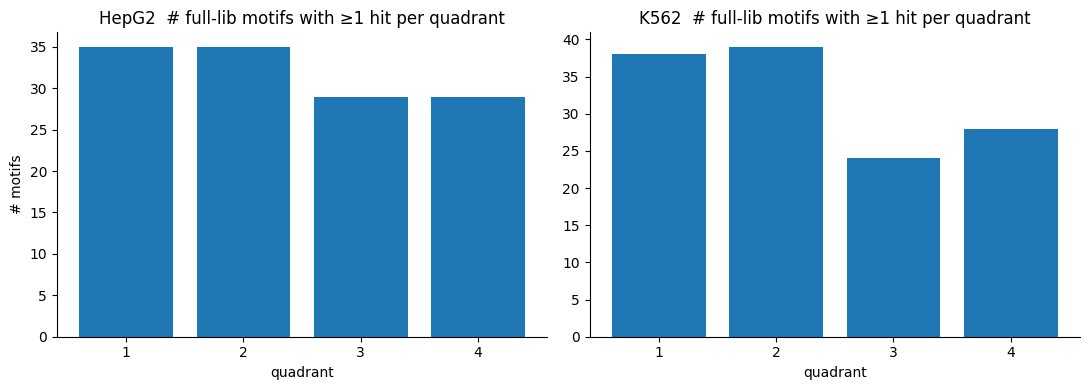

In [40]:
## summary stats per quadrant (full-lib patterns; quadrant = peak partition of finemo hits)
rows = []
for ct in CTS:
    h = hits[ct]
    for q in QUADS:
        sub = h[h['q'] == q]
        rows.append({'ct': ct, 'q': q,
                     'n_seqs': quad_n[q],
                     'n_hits': len(sub),
                     'n_motifs_with_hits': sub['motif_name'].nunique()})
summ = pd.DataFrame(rows)
print(summ.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, ct in zip(axes, CTS):
    sub = summ[summ['ct'] == ct].set_index('q').reindex(QUADS)
    ax.bar(QUADS, sub['n_motifs_with_hits'].values, color='#1f77b4')
    ax.set_xticks(QUADS); ax.set_xlabel('quadrant')
    ax.set_title(f'{ct}  # full-lib motifs with ≥1 hit per quadrant')
    for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
axes[0].set_ylabel('# motifs')
plt.tight_layout(); plt.show()

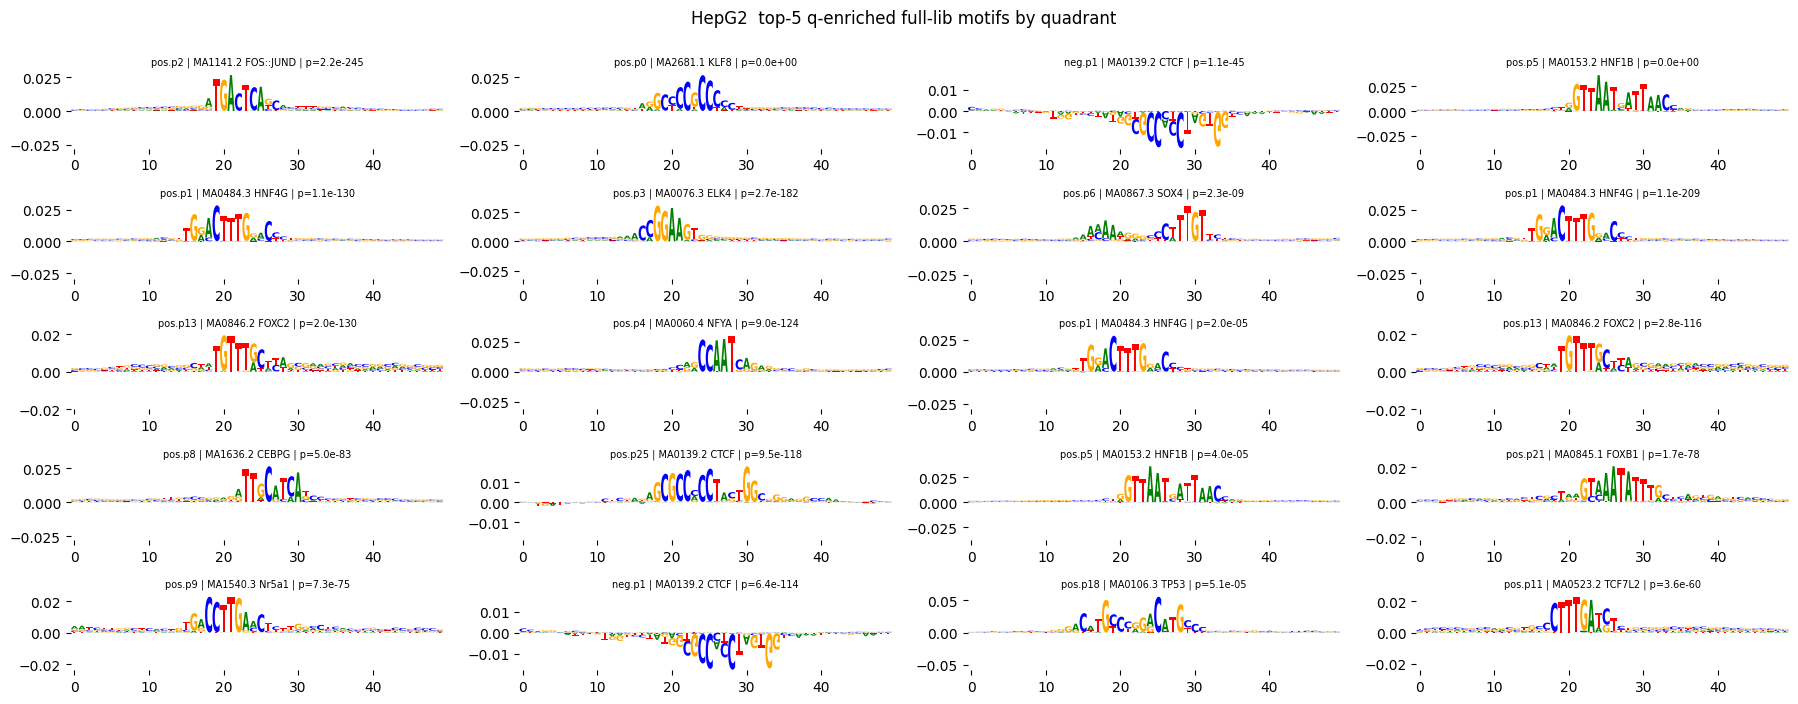

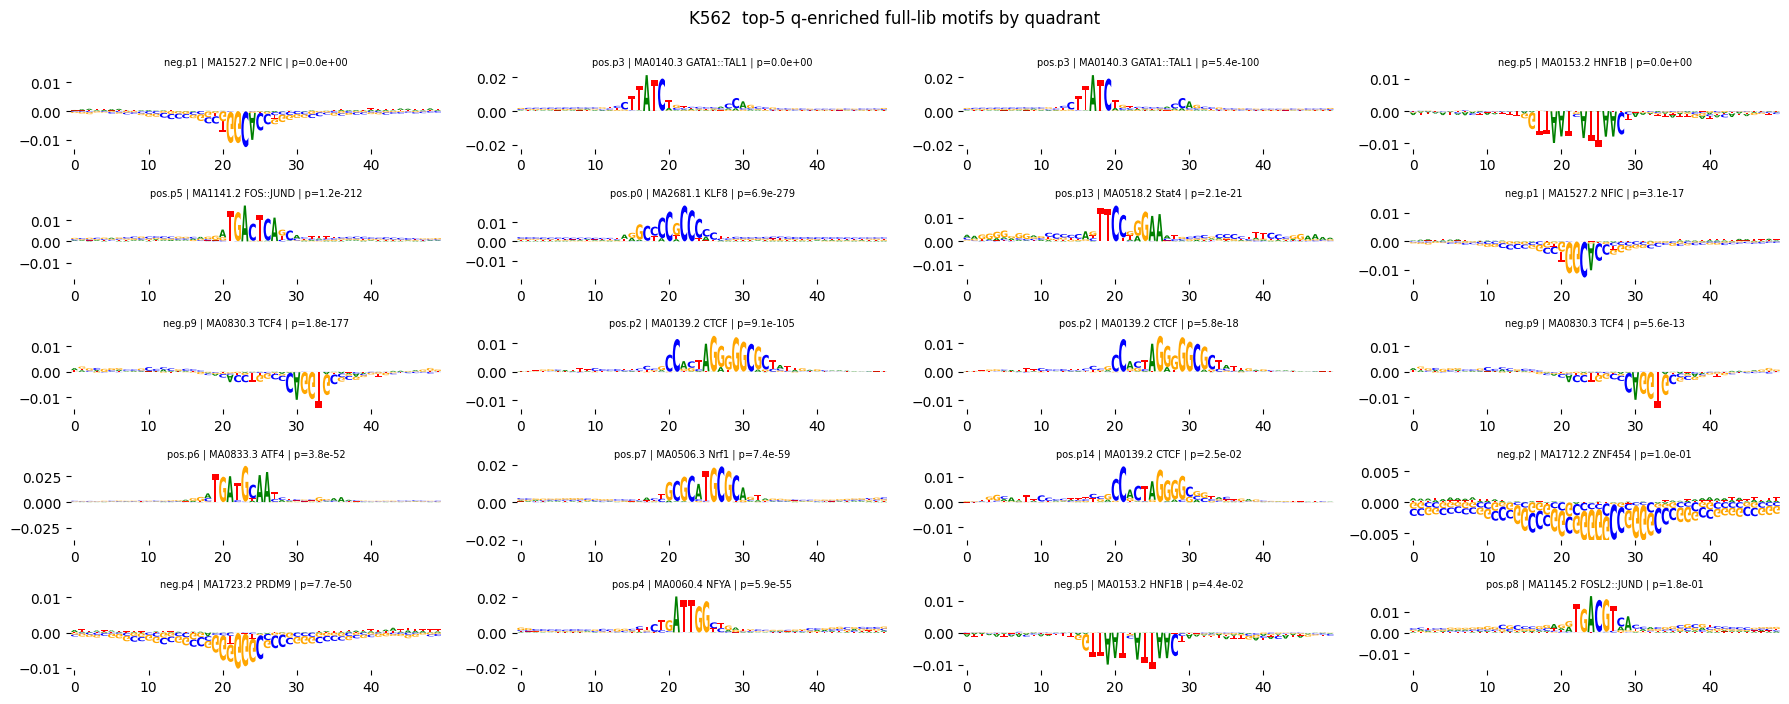

In [41]:
## CWMs of top-N q-enriched full-lib motifs per quadrant. Column per quadrant, one fig per ct.
TOP_N = 5
def cwm_for(h5, key):
    grp, pat = key.split('.')
    with h5py.File(h5) as f:
        return f[grp][pat]['contrib_scores'][...]

for ct in CTS:
    sub = enrich[enrich['ct'] == ct]
    top = sub.sort_values(['q', 'p']).groupby('q', as_index=False).head(TOP_N)
    fig, axes = plt.subplots(TOP_N, len(QUADS),
                             figsize=(4.5 * len(QUADS), 1.4 * TOP_N), squeeze=False)
    for ci, q in enumerate(QUADS):
        rows_q = top[top['q'] == q].reset_index(drop=True)
        axes[0, ci].set_title(f'Q{q}', fontsize=10)
        for r in range(TOP_N):
            ax = axes[r, ci]
            if r < len(rows_q):
                rec = rows_q.iloc[r]
                cwm = cwm_for(FULL_H5(ct), rec['motif'])
                yabs = max(abs(cwm).max() * 1.05, 1e-6)
                fast_logo(cwm.T, ax=ax, ylim=(-yabs, yabs))
                tag = rec['motif'].replace('_patterns.pattern_', '.p')
                ax.set_title(f'{tag} | {rec["tf"]} | p={rec["p"]:.1e}', fontsize=7)
            else:
                ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values(): sp.set_visible(False)
    fig.suptitle(f'{ct}  top-{TOP_N} q-enriched full-lib motifs by quadrant', y=1.0, fontsize=12)
    plt.tight_layout(); plt.show()

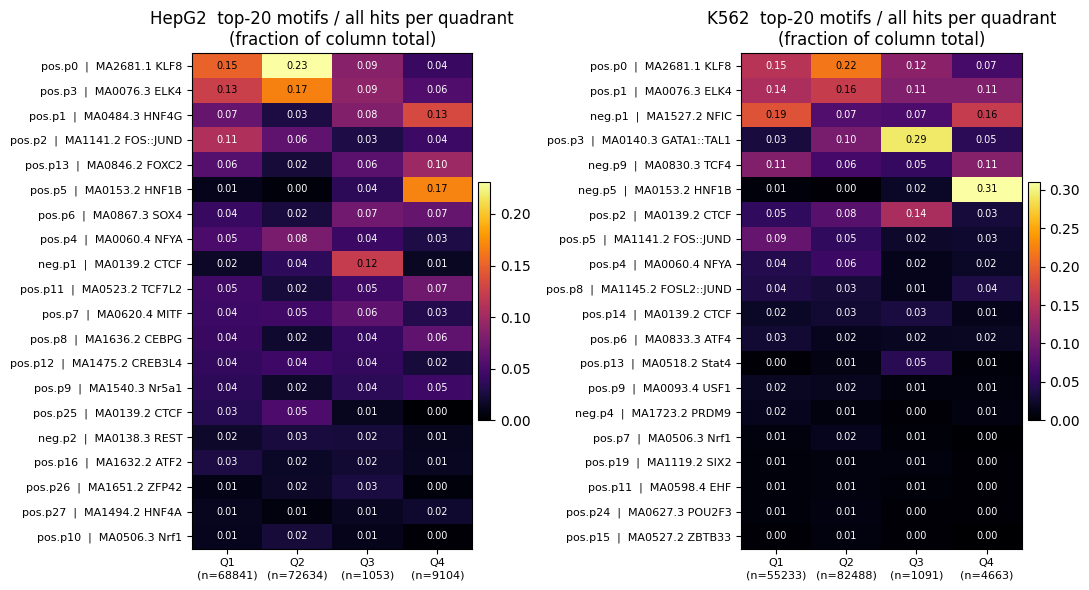

In [42]:
## enrichment heatmap: all full-lib finemo hits per quadrant. Column-normalized fractions.
TOP_PATS = 20
HITS_TSV    = lambda ct: os.path.join(REPO, 'genomic_targets/data/motif', ct, 'hits.tsv')
FULL_TOMTOM = os.path.join(MODISCO_DIR, 'tomtom_jaspar2026_full56k_enh230_default.json')
full_ann    = json.load(open(FULL_TOMTOM)) if os.path.exists(FULL_TOMTOM) else {}

n = len(df)
quad_of = np.zeros(n, dtype=int)
for q in QUADS: quad_of[quad_indices[q]] = q

fig, axes = plt.subplots(1, 2, figsize=(11, 6))
for ax, ct in zip(axes, CTS):
    h = pd.read_csv(HITS_TSV(ct), sep='\t', usecols=['peak_id', 'motif_name'])
    h['peak_id'] = h['peak_id'].astype(int)
    h = h[h['peak_id'] < n]
    h['q'] = quad_of[h['peak_id'].values]
    h = h[h['q'] != 0]

    raw = (h.groupby(['motif_name', 'q']).size()
             .unstack('q', fill_value=0)
             .reindex(columns=QUADS, fill_value=0))
    col_tot = raw.sum(axis=0)
    mat = raw.div(col_tot.replace(0, 1), axis=1)
    keep = mat.sum(axis=1).sort_values(ascending=False).head(TOP_PATS).index
    mat = mat.loc[keep]

    ylabels = [f'{m.replace("_patterns.pattern_", ".p")}  |  {full_ann.get(f"{ct}/{m}", "")}'
               for m in mat.index]
    xlabels = [f'Q{q}\n(n={int(col_tot[q])})' for q in QUADS]
    im = ax.imshow(mat.values, aspect='auto', cmap='inferno', vmin=0)
    ax.set_xticks(range(len(QUADS))); ax.set_xticklabels(xlabels, fontsize=8)
    ax.set_yticks(range(len(ylabels))); ax.set_yticklabels(ylabels, fontsize=8)
    ax.set_title(f'{ct}  top-{TOP_PATS} motifs / all hits per quadrant\n(fraction of column total)')
    vmax = mat.values.max() if mat.values.size else 1
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.values[i, j]
            if v > 0:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                        color='white' if v < vmax * 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
plt.tight_layout(); plt.show()

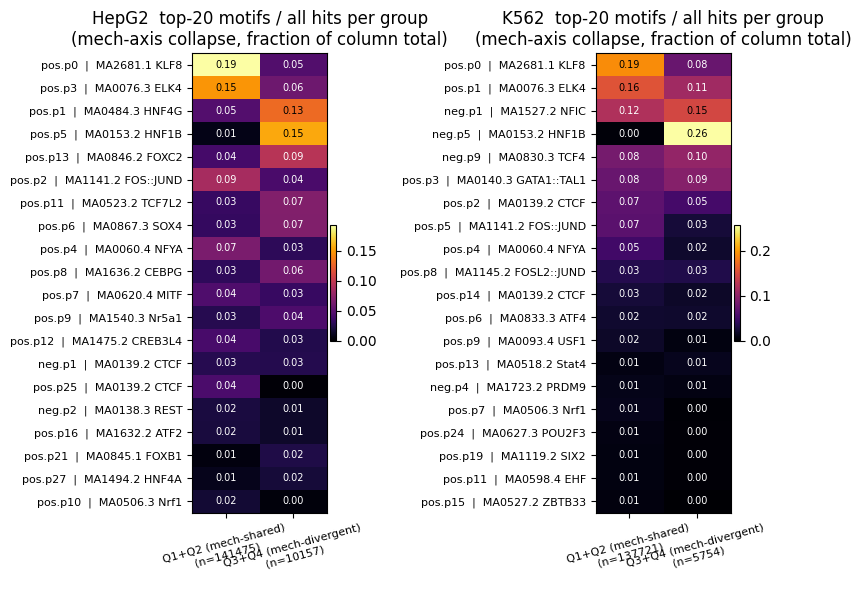

In [43]:
## mech-axis collapse: Q1+Q2 (cossim≥0, mech-shared) vs Q3+Q4 (cossim<0, mech-divergent). All hits.
GROUPS = {'Q1+Q2 (mech-shared)': [1, 2], 'Q3+Q4 (mech-divergent)': [3, 4]}
g_of   = {q: g for g, qs in GROUPS.items() for q in qs}
G_KEYS = list(GROUPS)

fig, axes = plt.subplots(1, 2, figsize=(8, 6))
for ax, ct in zip(axes, CTS):
    h = hits[ct].copy()
    h['g'] = h['q'].map(g_of)
    raw = (h.groupby(['motif_name', 'g']).size()
             .unstack('g', fill_value=0)
             .reindex(columns=G_KEYS, fill_value=0))
    col_tot = raw.sum(axis=0)
    mat = raw.div(col_tot.replace(0, 1), axis=1)
    keep = mat.sum(axis=1).sort_values(ascending=False).head(TOP_PATS).index
    mat = mat.loc[keep]

    ylabels = [f'{m.replace("_patterns.pattern_", ".p")}  |  {full_ann.get(f"{ct}/{m}", "")}'
               for m in mat.index]
    xlabels = [f'{g}\n(n={int(col_tot[g])})' for g in G_KEYS]
    im = ax.imshow(mat.values, aspect='auto', cmap='inferno', vmin=0)
    ax.set_xticks(range(len(G_KEYS))); ax.set_xticklabels(xlabels, rotation=15, fontsize=8)
    ax.set_yticks(range(len(ylabels))); ax.set_yticklabels(ylabels, fontsize=8)
    ax.set_title(f'{ct}  top-{TOP_PATS} motifs / all hits per group\n(mech-axis collapse, fraction of column total)')
    vmax = mat.values.max() if mat.values.size else 1
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.values[i, j]
            if v > 0:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                        color='white' if v < vmax * 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
plt.tight_layout(); plt.show()

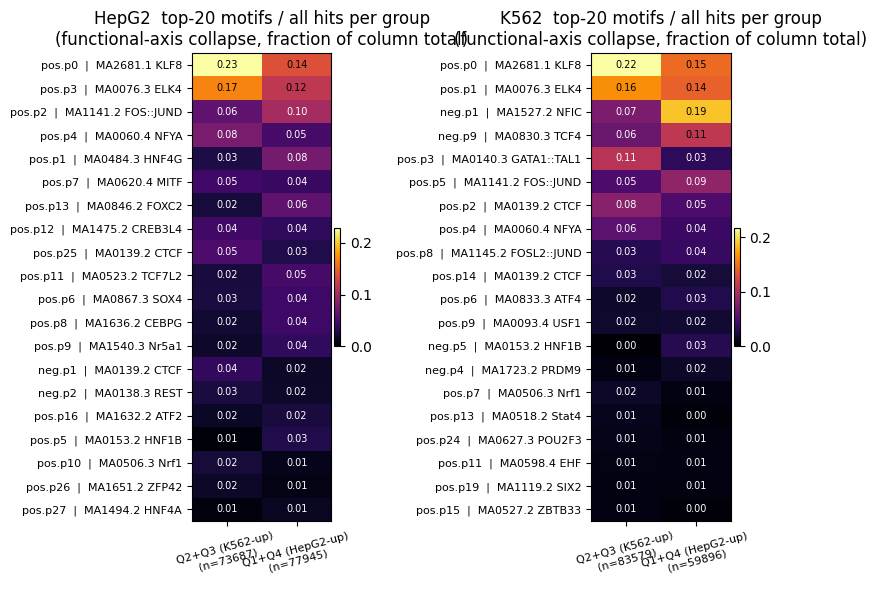

In [44]:
## functional-axis collapse: Q2+Q3 (lfc<0, K562-up) vs Q1+Q4 (lfc≥0, HepG2-up). All hits.
GROUPS = {'Q2+Q3 (K562-up)': [2, 3], 'Q1+Q4 (HepG2-up)': [1, 4]}
g_of   = {q: g for g, qs in GROUPS.items() for q in qs}
G_KEYS = list(GROUPS)

fig, axes = plt.subplots(1, 2, figsize=(8, 6))
for ax, ct in zip(axes, CTS):
    h = hits[ct].copy()
    h['g'] = h['q'].map(g_of)
    raw = (h.groupby(['motif_name', 'g']).size()
             .unstack('g', fill_value=0)
             .reindex(columns=G_KEYS, fill_value=0))
    col_tot = raw.sum(axis=0)
    mat = raw.div(col_tot.replace(0, 1), axis=1)
    keep = mat.sum(axis=1).sort_values(ascending=False).head(TOP_PATS).index
    mat = mat.loc[keep]

    ylabels = [f'{m.replace("_patterns.pattern_", ".p")}  |  {full_ann.get(f"{ct}/{m}", "")}'
               for m in mat.index]
    xlabels = [f'{g}\n(n={int(col_tot[g])})' for g in G_KEYS]
    im = ax.imshow(mat.values, aspect='auto', cmap='inferno', vmin=0)
    ax.set_xticks(range(len(G_KEYS))); ax.set_xticklabels(xlabels, rotation=15, fontsize=8)
    ax.set_yticks(range(len(ylabels))); ax.set_yticklabels(ylabels, fontsize=8)
    ax.set_title(f'{ct}  top-{TOP_PATS} motifs / all hits per group\n(functional-axis collapse, fraction of column total)')
    vmax = mat.values.max() if mat.values.size else 1
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.values[i, j]
            if v > 0:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                        color='white' if v < vmax * 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
plt.tight_layout(); plt.show()